### Configure environment

In [1]:
import chi, os, time, datetime
from chi import lease
from chi import server
from chi import context
from chi import hardware
from chi import network
from chi import ssh

In this section, we configure the Chameleon Python client.

For this experiment, we’re going to use the KVM@TACC site, which we indicate below.

We also need to specify the name of the Chameleon “project” that this experiment is part of. The project name will have the format “CHI-XXXXXX”, where the last part is a 6-digit number, and you can find it on your [user dashboard](https://chameleoncloud.org/user/dashboard/).

In the cell below, select the correct project ID, then run the cell.

In [2]:
context.version = "1.0" 
context.choose_project()
context.choose_site(default="KVM@TACC")
username = os.getenv('USER') # all exp resources will have this suffix

# configure openstacksdk for actions unsupported by python-chi
os_conn = chi.clients.connection()


### Configuration for federated learning experiment

In [3]:
username = os.getenv('USER')

node_conf = [
 {'name': "server",   'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-00",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-01",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-02",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-03",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-04",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-05",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-06",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-07",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-08",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}, 
 {'name': "client-09",  'flavor': 'm1.medium', 'image': 'CC-Ubuntu24.04', 'duration': 6, 'packages': []}
]
net_conf = [
     {"name": "net0", "subnet": "10.0.0.0/24", 
      "nodes": [
     {"name": "server",   "addr": "10.0.0.1"}, 
     {"name": "client-00",   "addr": "10.0.0.100"}, 
     {"name": "client-01",   "addr": "10.0.0.101"}, 
     {"name": "client-02",   "addr": "10.0.0.102"}, 
     {"name": "client-03",   "addr": "10.0.0.103"}, 
     {"name": "client-04",   "addr": "10.0.0.104"}, 
     {"name": "client-05",   "addr": "10.0.0.105"}, 
     {"name": "client-06",   "addr": "10.0.0.106"}, 
     {"name": "client-07",   "addr": "10.0.0.107"}, 
     {"name": "client-08",   "addr": "10.0.0.108"}, 
     {"name": "client-09",   "addr": "10.0.0.109"}
     ] }
]

### Reconnect to existing VMs (kernel restart recovery)

If your kernel restarted mid-experiment but your VMs are still alive (lease extended),
run the cell below **instead of** the "Configure resources" section.
It rebuilds `server_remotes` from the existing VM names without creating new leases or VMs.

In [ ]:
# Reconnect to existing VMs (run if kernel restarted but VMs still active)
# Skips lease/VM-creation/network cells below — just rebuilds server_remotes
if 'server_remotes' not in locals() or len(server_remotes) != len(node_conf):
    print("Reconnecting to", len(node_conf), "VMs...")
    server_ids = [chi.server.get_server_id(n['name'] + "_" + username) for n in node_conf]
    server_ips = []
    for sid in server_ids:
        s = chi.server.show_server(sid)
        for addrs in s.addresses.values():
            for a in addrs:
                if a.get('OS-EXT-IPS:type') == 'floating':
                    server_ips.append(a['addr'])
                    break
            else:
                continue
            break
    server_remotes = [chi.ssh.Remote(ip) for ip in server_ips]
    print("Reconnected — server_remotes has", len(server_remotes), "entries")
else:
    print("server_remotes already defined — skipping reconnect")

### Configure resources

Now, we will prepare the VMs and network links that our experiment requires.

First, we will prepare a “public” network that we will use for SSH access to our VMs -

In [ ]:
public_net = os_conn.network.create_network(name="public_net_" + username)
public_net_id = public_net.get("id")
public_subnet = os_conn.network.create_subnet(
    name="public_subnet_" + username,
    network_id=public_net.get("id"),
    ip_version='4',
    cidr="192.168.10.0/24",
    gateway_ip="192.168.10.1",
    is_dhcp_enabled = True
)

Next, we will prepare the “experiment” networks -

In [ ]:
nets = []
net_ids = []
subnets = []
for n in net_conf:
    exp_net = os_conn.network.create_network(name="exp_" + n['name']  + '_' + username)
    exp_net_id = exp_net.get("id")
    os_conn.network.update_network(exp_net, is_port_security_enabled=False)
    exp_subnet = os_conn.network.create_subnet(
        name="exp_subnet_" + n['name']  + '_' + username,
        network_id=exp_net.get("id"),
        ip_version='4',
        cidr=n['subnet'],
        gateway_ip=None,
        is_dhcp_enabled = False
    )
    nets.append(exp_net)
    net_ids.append(exp_net_id)
    subnets.append(exp_subnet)

Now we create the VMs -

In [ ]:
servers = []
server_ids = []
for i, n in enumerate(node_conf, start=10):

    # reserve the node
    l = lease.Lease(n['name'] + "_" + username, duration=datetime.timedelta(hours=n.get('duration', 6)))
    l.add_flavor_reservation(id=chi.server.get_flavor_id(n['flavor']), amount=1)
    l.submit(idempotent=True)
    flavor_uuid = l.get_reserved_flavors()[0].id
    
    image_uuid = os_conn.image.find_image(n['image']).id

    # find out details of exp interface(s)
    nics = [{'net-id': chi.network.get_network_id( "exp_" + net['name']  + '_' + username ), 'v4-fixed-ip': node['addr']} for net in net_conf for node in net['nodes'] if node['name']==n['name']]
    # also include a public network interface
    nics.insert(0, {"net-id": public_net_id, "v4-fixed-ip":"192.168.10." + str(i)})
    server = chi.server.create_server(
        server_name=n['name'] + "_" + username,
        image_id=image_uuid,
        flavor_id=flavor_uuid,
        nics=nics
    )
    servers.append(server)
    server_ids.append(chi.server.get_server(n['name'] + "_" + username).id)

We wait for all servers to come up before we proceed -

In [ ]:
for server_id in server_ids:
    chi.server.wait_for_active(server_id)

Next, we will set up SSH access to the VMs.

First, we will make sure the “public” network is connected to the Internet. Then, we will configure it to permit SSH access on port 22 for each port connected to this network.

In [ ]:
# connect them to the Internet on the "public" network (e.g. for software installation)
router = chi.network.create_router('inet_router_' + username, gw_network_name='public')
chi.network.add_subnet_to_router(router.get("id"), public_subnet.get("id"))

In [ ]:
# prepare SSH access on the servers
# WARNING: this relies on undocumented behavior of associate_floating_ip 
# that it associates the IP with the first port on the server
server_ips = []
for server_id in server_ids:
    ip = chi.server.associate_floating_ip(server_id)
    server_ips.append(ip)

Note: The following cells assumes that a security group named “Allow SSH” already exists in your project, and is configured to allow SSH access on port 22. If you have done the “Hello, Chameleon” experiment then you already have this security group.

In [ ]:
security_group_id = os_conn.get_security_group("Allow SSH").id
for port in chi.network.list_ports(): 
    if port['port_security_enabled'] and port['network_id']==public_net.get("id"):
        os_conn.network.update_port(port['id'], security_groups=[security_group_id])

In [ ]:
for ip in server_ips:
    chi.server.wait_for_tcp(ip, port=22)

Finally, we need to configure our resources, including software package installation and network configuration.

In [ ]:
server_remotes = [chi.ssh.Remote(ip) for ip in server_ips]

In [ ]:
# configure an IP address on each port that is supposed to have one
for port in chi.network.list_ports():
    if port['network_id'] in net_ids:
        i = server_ids.index(port['device_id'])
        j = net_ids.index(port['network_id'])
        port_conf =  [item for item in net_conf[j]['nodes'] if item['name'] == node_conf[i]['name'] ][0]
        if port_conf['addr']:
            server_remotes[i].run( "sudo ip addr flush dev $(ip --br link | grep '" + port['mac_address'] + "' | awk '{print $1}')" )
            cmd_prefix = "sudo ip addr add " + port_conf['addr'] + "/" + net_conf[j]['subnet'].split("/")[1] 
            server_remotes[i].run( cmd_prefix + " dev $(ip --br link | grep '" + port['mac_address'] + "' | awk '{print $1}')" )
        else:
            server_remotes[i].run( "sudo ip addr flush dev $(ip --br link | grep '" + port['mac_address'] + "' | awk '{print $1}')" )

In [ ]:
for i, n in enumerate(node_conf):
    remote = server_remotes[i]
    # enable forwarding
    remote.run(f"sudo sysctl -w net.ipv4.ip_forward=1") 
    remote.run(f"sudo firewall-cmd --zone=trusted --add-source=192.168.0.0/16")
    remote.run(f"sudo firewall-cmd --zone=trusted --add-source=172.16.0.0/12")
    remote.run(f"sudo firewall-cmd --zone=trusted --add-source=10.0.0.0/8")
    # configure static routes
    for r in route_conf: 
        if n['name'] in r['nodes']:
            remote.run(f"sudo ip route add " + r['addr'] + " via " + r['gw']) 

In [ ]:
for i, n in enumerate(node_conf):
    # install packages
    if len(n['packages']):
            remote = server_remotes[i]
            remote.run(f"sudo apt update; sudo apt -y install " + " ".join(n['packages'])) 

In [ ]:
# prepare a "hosts" file that has names and addresses of every node
hosts_txt = [ "%s\t%s" % ( n['addr'], n['name'] ) for net in net_conf  for n in net['nodes'] if type(n) is dict and n['addr']]
for remote in server_remotes:
    for h in hosts_txt:
        remote.run("echo %s | sudo tee -a /etc/hosts > /dev/null" % h)

In [ ]:
# turn segment offload off
for port in chi.network.list_ports():
    if port['network_id'] in net_ids:
        i = server_ids.index(port['device_id'])
        j = net_ids.index(port['network_id'])
        for offload in ["gro", "gso", "tso"]:
            server_remotes[i].run( "sudo ethtool -K $(ip --br link | grep '" + port['mac_address'] + "' | awk '{print $1}') " + offload + " off" )

### Draw the network topology

The following cells will draw the network topology, for your reference.

In [ ]:
!pip install networkx

In [ ]:
nodes = [ (n['name'], {'color': 'pink'}) for n in net_conf ] + [(n['name'], {'color': 'lightblue'}) for n in node_conf ]
edges = [(net['name'], node['name'], 
          {'label': node['addr'] + '/' + net['subnet'].split("/")[1] }) if node['addr'] else (net['name'], node['name']) for net in net_conf for node in net['nodes'] ]

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
plt.figure(figsize=(len(nodes),len(nodes)))
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)
pos = nx.spring_layout(G)
nx.draw(G, pos, node_shape='s',  
        node_color=[n[1]['color'] for n in nodes], 
        node_size=[len(n[0])*400 for n in nodes],  
        with_labels=True);
nx.draw_networkx_edge_labels(G,pos,
                             edge_labels=nx.get_edge_attributes(G,'label'),
                             font_color='gray',  font_size=8, rotate=False);

In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
slice_info = [{'Name': n['name'], 'SSH command': "ssh cc@" + server_ips[i] } for i, n in enumerate(node_conf)]
pd.DataFrame(slice_info).set_index('Name')

### Install FL code on experiment VMs

In [4]:
server_ids = []
for n in node_conf:
    server_ids.append(chi.server.get_server(n['name'] + "_" + username).id)

server_ips = []
for n in node_conf:
    server_ips.append(chi.server.get_server(n['name'] + "_" + username).get_floating_ip())

server_remotes = [chi.ssh.Remote(ip) for ip in server_ips]

The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The python binding code in neutronclient is deprecated in favor of OpenstackSDK, please use that as this will be removed in a future release.
The py

In [5]:
for remote in server_remotes:
  remote.run("rm -rf federated-chi; git clone https://github.com/Sabrinaaddo07/federated-chi.git")

/opt/conda/lib/python3.12/site-packages/paramiko/client.py:850: UserWarning: Unknown ssh-ed25519 host key for 129.114.26.169: b'c3258112b8212f4b82961e03da493648'
  warnings.warn(
Cloning into 'federated-chi'...
/opt/conda/lib/python3.12/site-packages/paramiko/client.py:850: UserWarning: Unknown ssh-ed25519 host key for 129.114.26.54: b'c2489e27d9f49ae9b37ed9a80b3640be'
  warnings.warn(
Cloning into 'federated-chi'...
/opt/conda/lib/python3.12/site-packages/paramiko/client.py:850: UserWarning: Unknown ssh-ed25519 host key for 129.114.26.153: b'53a5210d13198328eec772677fe738ac'
  warnings.warn(
Cloning into 'federated-chi'...
/opt/conda/lib/python3.12/site-packages/paramiko/client.py:850: UserWarning: Unknown ssh-ed25519 host key for 129.114.27.237: b'c3e4da936e1ec4025763479d698cc076'
  warnings.warn(
Cloning into 'federated-chi'...
/opt/conda/lib/python3.12/site-packages/paramiko/client.py:850: UserWarning: Unknown ssh-ed25519 host key for 129.114.26.84: b'fabaa641681c01379a84d3062eb3e0

In [6]:
for remote in server_remotes:
    remote.run("sudo apt update; sudo apt -y install python3-pip")

Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:2 http://security.ubuntu.com/ubuntu noble-security InRelease
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Get:5 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [1031 kB]
Get:6 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [1656 kB]
Fetched 2813 kB in 1s (5361 kB/s)
Reading package lists...
Building dependency tree...
Reading state information...
12 packages can be upgraded. Run 'apt list --upgradable' to see them.


Reading package lists...
Building dependency tree...
Reading state information...
python3-pip is already the newest version (24.0+dfsg-1ubuntu1.3).
0 upgraded, 0 newly installed, 0 to remove and 12 not upgraded.


Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:2 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists...
Building dependency tree...
Reading state information...
12 packages can be upgraded. Run 'apt list --upgradable' to see them.


Reading package lists...
Building dependency tree...
Reading state information...
python3-pip is already the newest version (24.0+dfsg-1ubuntu1.3).
0 upgraded, 0 newly installed, 0 to remove and 12 not upgraded.


Hit:1 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:2 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists...
Building dependency tree...
Reading state information...
12 packages can be upgraded. Run 'apt list --upgradable' to see them.


...

Reading package lists...
Building dependency tree...
Reading state information...
python3-pip is already the newest version (24.0+dfsg-1ubuntu1.3).
0 upgraded, 0 newly installed, 0 to remove and 12 not upgraded.


Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Get:5 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [1031 kB]
Get:6 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [1656 kB]
Fetched 2813 kB in 1s (2085 kB/s)
Reading package lists...
Building dependency tree...
Reading state information...
12 packages can be upgraded. Run 'apt list --upgradable' to see them.


Reading package lists...
Building dependency tree...
Reading state information...
python3-pip is already the newest version (24.0+dfsg-1ubuntu1.3).
0 upgraded, 0 newly installed, 0 to remove and 12 not upgraded.


Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Get:5 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [1031 kB]
Get:6 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [1656 kB]
Fetched 2813 kB in 1s (2911 kB/s)
Reading package lists...
Building dependency tree...
Reading state information...
12 packages can be upgraded. Run 'apt list --upgradable' to see them.


Reading package lists...
Building dependency tree...
Reading state information...
python3-pip is already the newest version (24.0+dfsg-1ubuntu1.3).
0 upgraded, 0 newly installed, 0 to remove and 12 not upgraded.


In [7]:
for remote in server_remotes:
  remote.run("cd federated-chi; pip install -r requirements.txt --break-system-packages")

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


### Run baseline experiment

In [36]:
for remote in server_remotes:
    try:
        remote.run("sudo killall python3")
    except:
        pass

python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found


In [20]:
server_remotes[0].run(
    "nohup bash -lc 'cd federated-chi/baseline && python3 -u server.py' > server.log 2>&1 &",
    hide=False,
    warn=True,
)

<Result cmd="nohup bash -lc 'cd federated-chi/baseline && python3 -u server.py' > server.log 2>&1 &" exited=0>

In [21]:
server_remotes[0].run("cat server.log")

  RANDOM SAMPLING EXPERIMENT
  10 total clients  |  10 picked per round

  Each round: a random subset of K clients participates.
  Selection is independent every round.

  Open new terminals and run (all 10 before round 1):
    python3 client.py --cid 0 --num_clients 10
    python3 client.py --cid 1 --num_clients 10
    python3 client.py --cid 2 --num_clients 10
    python3 client.py --cid 3 --num_clients 10
    python3 client.py --cid 4 --num_clients 10
    python3 client.py --cid 5 --num_clients 10
    python3 client.py --cid 6 --num_clients 10
    python3 client.py --cid 7 --num_clients 10
    python3 client.py --cid 8 --num_clients 10
    python3 client.py --cid 9 --num_clients 10

  Ctrl+C any client to remove it; server keeps going.
  Ctrl+C the server to stop entirely.

  Server listening on 10.0.0.1:8080
  Waiting for 10 clients...

Port in server address 10.0.0.1:8080 is already in use.
                                                                                          

<Result cmd='cat server.log' exited=0>

In [11]:
for cid, remote in enumerate(server_remotes[1:]):
    print(cid)
    remote.run(
        f"nohup bash -lc 'cd federated-chi/baseline && python3 -u client.py --cid {cid} --num_clients 10 --server_address 10.0.0.1:8080' > client_{cid}.log 2>&1 &",
    hide=False,
    warn=True,
    )

0
1
2
3
4
5
6
7
8
9


In [38]:
import time

for remote in server_remotes:
    try:
        remote.run("sudo killall python3")
    except:
        pass

server_remotes[0].run(
    "nohup bash -lc 'cd federated-chi/baseline && python3 -u server.py' > server.log 2>&1 &",
    hide=False, warn=True,
)

for cid, remote in enumerate(server_remotes[1:]):
    remote.run(
        f"nohup bash -lc 'cd federated-chi/baseline && python3 -u client.py --cid {cid} --num_clients 10 --server_address 10.0.0.1:8080' > client_{cid}.log 2>&1 &",
        hide=False, warn=True,
    )

for _ in range(200):
    out = server_remotes[0].run(
        "grep -c 'Global test accuracy' server.log 2>/dev/null || echo 0",
        hide=True,
    ).stdout.strip()
    if out:
        print(f"  Baseline: rounds {out}/40", end="\r")
    if out == "40":
        print("\n  Baseline: done!")
        break
    time.sleep(10)

print("\nBaseline experiment finished!")

python3: no process found
python3: no process found
python3: no process found



--- K=2 of 10 ---


python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found


  K=2: rounds 0


python3: no process found
python3: no process found
python3: no process found


...

  K=6: rounds 0


python3: no process found
python3: no process found
python3: no process found
python3: no process found


  K=6: rounds 40/40
  K=6: done!

--- K=10 of 10 ---


python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found
python3: no process found


  K=10: rounds 0
  K=10: rounds 40/40
  K=10: done!

All experiments finished!


### Client Selection Experiment

In [ ]:
import time

for remote in server_remotes:
    try:
        remote.run("sudo killall python3")
    except:
        pass

for pct in [100, 80, 60, 40, 20]:
    k = int(10 * pct / 100)

    server_remotes[0].run(
        f"nohup bash -lc 'cd federated-chi/client_selection && python3 -u server.py --clients_per_round {k}' > server_{pct}.log 2>&1 &",
        hide=False, warn=True,
    )

    for cid, remote in enumerate(server_remotes[1:]):
        remote.run(
            f"nohup bash -lc 'cd federated-chi/client_selection && python3 -u client.py --cid {cid} --num_clients 10 --server_address 10.0.0.1:8080' > client_{cid}.log 2>&1 &",
            hide=False, warn=True,
        )

    for _ in range(200):
        out = server_remotes[0].run(
            "grep -c 'Global test accuracy' server_{}.log 2>/dev/null || echo 0".format(pct),
            hide=True,
        ).stdout.strip()
        if out:
            print(f"  {pct}%: rounds {out}/40", end="\r")
        if out == "40":
            print(f"\n  {pct}%: done!")
            break
        time.sleep(10)

    server_remotes[0].run(
        f"cp federated-chi/client_selection/results_clientsel.csv federated-chi/client_selection/results_clientsel_{pct}.csv",
        hide=True,
    )

print("\nAll client selection experiments finished!")

### Client Selection — Plot Results

In [ ]:
import io
import csv
import matplotlib.pyplot as plt
import numpy as np

RATES = [100, 80, 60, 40, 20]
COLORS = ["#2e86ab", "#e67e22", "#27ae60", "#e74c3c", "#8e44ad"]

data = {}
for rate in RATES:
    result = server_remotes[0].run(
        f"cat federated-chi/client_selection/results_clientsel_{rate}.csv",
        hide=True,
    )
    rows = list(csv.DictReader(io.StringIO(result.stdout)))
    data[rate] = {
        "rounds": [int(r["round"]) for r in rows],
        "accs": [float(r["global_accuracy"]) for r in rows],
        "overhead_mb": [float(r["cumulative_overhead_bytes"]) / 1e6 for r in rows],
    }

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for i, rate in enumerate(RATES):
    d = data[rate]
    c = COLORS[i]
    label = f"{rate}% ({int(10 * rate / 100)} clients/round)"
    ax1.plot(d["rounds"], d["accs"], color=c, marker="o",
             linewidth=1.5, markersize=3, label=label)
    ax2.plot(d["overhead_mb"], d["accs"], color=c, marker="o",
             linewidth=1.5, markersize=3, label=label)

ax1.set_xlabel("Round", fontsize=12)
ax1.set_ylabel("Global Test Accuracy", fontsize=12)
ax1.set_title("Accuracy vs Rounds", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9, loc="lower right")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2.set_xlabel("Cumulative Overhead (MB)", fontsize=12)
ax2.set_ylabel("Global Test Accuracy", fontsize=12)
ax2.set_title("Accuracy vs Overhead", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9, loc="lower right")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

header = f"{'Rate':<8}{'Final Acc':<12}{'Peak Acc':<12}{'Total MB':<12}{'Time (s)':<10}"
print()
print(header)
print("-" * len(header))
for rate in RATES:
    d = data[rate]
    print(f"{rate:<8}{d['accs'][-1]:<12.4f}{max(d['accs']):<12.4f}{d['overhead_mb'][-1]:<12.2f}{'—':<10}")

### Structured Updates Experiment

In [ ]:
import time

for remote in server_remotes:
    try:
        remote.run("sudo killall python3")
    except:
        pass

for rate in [100, 50, 25, 10, 5]:
    update_rate = rate / 100.0

    server_remotes[0].run(
        f"nohup bash -lc 'cd federated-chi/structured_updates && python3 -u server.py --update_rate {update_rate}' > server_{rate}.log 2>&1 &",
        hide=False, warn=True,
    )

    for cid, remote in enumerate(server_remotes[1:]):
        remote.run(
            f"nohup bash -lc 'cd federated-chi/structured_updates && python3 -u client.py --cid {cid} --num_clients 10 --update_rate {update_rate} --server_address 10.0.0.1:8080' > client_{cid}.log 2>&1 &",
            hide=False, warn=True,
        )

    for _ in range(200):
        out = server_remotes[0].run(
            "grep -c 'Global test accuracy' server_{}.log 2>/dev/null || echo 0".format(rate),
            hide=True,
        ).stdout.strip()
        if out:
            print(f"  {rate}%: rounds {out}/40", end="\r")
        if out == "40":
            print(f"\n  {rate}%: done!")
            break
        time.sleep(10)

    server_remotes[0].run(
        f"cp federated-chi/structured_updates/results_structuredup.csv federated-chi/structured_updates/results_structuredup_{rate}.csv",
        hide=True,
    )

print("\nAll structured updates experiments finished!")

### Structured Updates — Plot Results

In [ ]:
import io
import csv
import matplotlib.pyplot as plt
import numpy as np

RATES = [100, 50, 25, 10, 5]
COLORS = ["#2e86ab", "#e67e22", "#27ae60", "#e74c3c", "#8e44ad"]

data = {}
for rate in RATES:
    result = server_remotes[0].run(
        f"cat federated-chi/structured_updates/results_structuredup_{rate}.csv",
        hide=True,
    )
    rows = list(csv.DictReader(io.StringIO(result.stdout)))
    data[rate] = {
        "rounds": [int(r["round"]) for r in rows],
        "accs": [float(r["global_accuracy"]) for r in rows],
        "overhead_mb": [float(r["cumulative_overhead_bytes"]) / 1e6 for r in rows],
    }

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for i, rate in enumerate(RATES):
    d = data[rate]
    c = COLORS[i]
    label = f"{rate}% params/update"
    ax1.plot(d["rounds"], d["accs"], color=c, marker="o",
             linewidth=1.5, markersize=3, label=label)
    ax2.plot(d["overhead_mb"], d["accs"], color=c, marker="o",
             linewidth=1.5, markersize=3, label=label)

ax1.set_xlabel("Round", fontsize=12)
ax1.set_ylabel("Global Test Accuracy", fontsize=12)
ax1.set_title("Accuracy vs Rounds", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9, loc="lower right")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2.set_xlabel("Cumulative Overhead (MB)", fontsize=12)
ax2.set_ylabel("Global Test Accuracy", fontsize=12)
ax2.set_title("Accuracy vs Overhead", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9, loc="lower right")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

header = f"{'Params':<10}{'Final Acc':<12}{'Peak Acc':<12}{'Total MB':<12}{'Time (s)':<10}"
print()
print(header)
print("-" * len(header))
for rate in RATES:
    d = data[rate]
    print(f"{rate:<10}{d['accs'][-1]:<12.4f}{max(d['accs']):<12.4f}{d['overhead_mb'][-1]:<12.2f}{'—':<10}")

### Data Distribution Experiment (IID vs Non-IID)

In [ ]:
import time

for remote in server_remotes:
    try:
        remote.run("sudo killall python3")
    except:
        pass

for dist in ["iid", "noniid"]:

    server_remotes[0].run(
        f"nohup bash -lc 'cd federated-chi/data_distribution && python3 -u server.py --distribution {dist}' > server_{dist}.log 2>&1 &",
        hide=False, warn=True,
    )

    for cid, remote in enumerate(server_remotes[1:]):
        remote.run(
            f"nohup bash -lc 'cd federated-chi/data_distribution && python3 -u client.py --cid {cid} --num_clients 10 --distribution {dist} --server_address 10.0.0.1:8080' > client_{cid}.log 2>&1 &",
            hide=False, warn=True,
        )

    for _ in range(200):
        out = server_remotes[0].run(
            "grep -c 'Global test accuracy' server_{}.log 2>/dev/null || echo 0".format(dist),
            hide=True,
        ).stdout.strip()
        if out:
            print(f"  {dist}: rounds {out}/40", end="\r")
        if out == "40":
            print(f"\n  {dist}: done!")
            break
        time.sleep(10)

    server_remotes[0].run(
        f"cp federated-chi/data_distribution/results_distribution.csv federated-chi/data_distribution/results_distribution_{dist}.csv",
        hide=True,
    )

print("\nAll data distribution experiments finished!")

### Data Distribution — Plot Results

In [ ]:
import io
import csv
import matplotlib.pyplot as plt
import numpy as np

DISTS = ["iid", "noniid"]
DIST_LABELS = ["IID", "Non-IID"]
COLORS = ["#2e86ab", "#e74c3c"]
MARKERS = ["o", "s"]

data = {}
for dist, label in zip(DISTS, DIST_LABELS):
    result = server_remotes[0].run(
        f"cat federated-chi/data_distribution/results_distribution_{dist}.csv",
        hide=True,
    )
    rows = list(csv.DictReader(io.StringIO(result.stdout)))
    data[label] = {
        "rounds": [int(r["round"]) for r in rows],
        "accs": [float(r["global_accuracy"]) for r in rows],
        "overhead_mb": [float(r["cumulative_overhead_bytes"]) / 1e6 for r in rows],
    }

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for i, label in enumerate(DIST_LABELS):
    d = data[label]
    c = COLORS[i]
    m = MARKERS[i]
    ax1.plot(d["rounds"], d["accs"], color=c, marker=m,
             linewidth=1.5, markersize=4, label=label)
    ax2.plot(d["overhead_mb"], d["accs"], color=c, marker=m,
             linewidth=1.5, markersize=4, label=label)

ax1.set_xlabel("Round", fontsize=12)
ax1.set_ylabel("Global Test Accuracy", fontsize=12)
ax1.set_title("Accuracy vs Rounds", fontsize=13, fontweight="bold")
ax1.legend(fontsize=11, loc="lower right")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2.set_xlabel("Cumulative Overhead (MB)", fontsize=12)
ax2.set_ylabel("Global Test Accuracy", fontsize=12)
ax2.set_title("Accuracy vs Overhead", fontsize=13, fontweight="bold")
ax2.legend(fontsize=11, loc="lower right")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

header = f"{'Distribution':<12}{'Final Acc':<12}{'Peak Acc':<12}{'Total MB':<12}{'Time (s)':<10}"
print()
print(header)
print("-" * len(header))
for label in DIST_LABELS:
    d = data[label]
    print(f"{label:<12}{d['accs'][-1]:<12.4f}{max(d['accs']):<12.4f}{d['overhead_mb'][-1]:<12.2f}{'—':<10}")

### Revised Client Selection — Health Check

In [ ]:
dead = []
for i, remote in enumerate(server_remotes):
    result = remote.run(
        "test -d federated-chi/revised_client_selection && echo OK || echo MISSING",
        warn=True, hide=True, timeout=10,
    )
    status = result.stdout.strip()
    print(f"  VM {i} (cid {i-1 if i > 0 else 'server'}): {status}")
    if status != "OK":
        dead.append(i)

if dead:
    print(f"\n  {len(dead)} VMs DEAD: {dead}")
    print("  M=10 will hang. Run repair or skip M=10.")
else:
    print(f"\n  All {len(server_remotes)} VMs ready!")

if len(server_remotes) < 11:
    print(f"  Only {len(server_remotes)} VMs connected — expecting 11")

### Revised Client Selection — Download CIFAR-10 (first run only)

In [ ]:
import time

print("Downloading CIFAR-10 on all VMs (first run only, ~2 min)...")
for i, remote in enumerate(server_remotes):
    result = remote.run(
        "cd federated-chi/revised_client_selection && python3 -c 'from common import _load_cifar10; _load_cifar10(); print(\"OK\")'",
        warn=True, timeout=300,
    )
    status = result.stdout.strip()
    print(f"  VM {i}: {status}")
print("All VMs have CIFAR-10 cached! Ready for experiment.")

### Revised Client Selection Baseline (M = 1, 2, 4, 6, 8, 10)

In [ ]:
import time

for remote in server_remotes:
    try:
        remote.run("sudo killall python3")
    except:
        pass

for M in [1, 2, 4, 6, 8, 10]:

    server_remotes[0].run(
        f"nohup bash -lc 'cd federated-chi/revised_client_selection && python3 -u server.py --clients_per_round {M} --num_rounds 75' > server_{M}.log 2>&1 &",
        hide=False, warn=True,
    )

    for cid, remote in enumerate(server_remotes[1:]):
        remote.run(
            f"nohup bash -lc 'cd federated-chi/revised_client_selection && python3 -u client.py --cid {cid} --num_clients 10 --server_address 10.0.0.1:8080' > client_{cid}.log 2>&1 &",
            hide=False, warn=True,
        )

    for _ in range(300):
        out = server_remotes[0].run(
            "grep -c 'Global test accuracy' server_{}.log 2>/dev/null || echo 0".format(M),
            hide=True,
        ).stdout.strip()
        if out:
            print(f"  M={M}: rounds {out}/75", end="\r")
        if out == "75":
            print(f"\n  M={M}: done!")
            break
        time.sleep(10)

    server_remotes[0].run(
        f"cp federated-chi/revised_client_selection/results_revised_clientsel.csv federated-chi/revised_client_selection/results_revised_clientsel_{M}.csv",
        hide=True,
    )

print("\nAll revised client selection experiments finished!")

### Revised Client Selection — Plot Results

In [ ]:
import io
import csv
import matplotlib.pyplot as plt
import numpy as np

TARGET = 0.90
M_VALUES = [1, 2, 4, 6, 8, 10]
COLORS = ["#8e44ad", "#e74c3c", "#e67e22", "#f1c40f", "#27ae60", "#2e86ab"]
MARKERS = ["x", "s", "^", "D", "v", "o"]

data = {}
for m in M_VALUES:
    result = server_remotes[0].run(
        f"cat federated-chi/revised_client_selection/results_revised_clientsel_{m}.csv",
        hide=True,
    )
    rows = list(csv.DictReader(io.StringIO(result.stdout)))
    data[m] = {
        "rounds": [int(r["round"]) for r in rows],
        "accs": [float(r["global_accuracy"]) for r in rows],
        "overhead_mb": [float(r["cumulative_overhead_bytes"]) / 1e6 for r in rows],
        "elapsed": [float(r["elapsed_time_seconds"]) for r in rows],
    }

crossings = {}
for m in M_VALUES:
    d = data[m]
    idx = next((i for i, a in enumerate(d["accs"]) if a >= TARGET), None)
    if idx is not None:
        crossings[m] = {
            "round": d["rounds"][idx],
            "overhead_mb": d["overhead_mb"][idx],
            "elapsed": d["elapsed"][idx],
        }

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))

for i, m in enumerate(M_VALUES):
    d = data[m]
    c = COLORS[i]
    mk = MARKERS[i]
    label = f"M={m}"
    ax1.plot(d["rounds"], d["accs"], color=c, marker=mk,
             linewidth=1.5, markersize=3, label=label)
    ax2.plot(d["overhead_mb"], d["accs"], color=c, marker=mk,
             linewidth=1.5, markersize=3, label=label)
    ax3.plot(d["elapsed"], d["accs"], color=c, marker=mk,
             linewidth=1.5, markersize=3, label=label)
    if m in crossings:
        c = crossings[m]
        ax1.plot(c["round"], TARGET, color=COLORS[i], marker="D",
                 markersize=8, zorder=5)
        ax2.plot(c["overhead_mb"], TARGET, color=COLORS[i], marker="D",
                 markersize=8, zorder=5)
        ax3.plot(c["elapsed"], TARGET, color=COLORS[i], marker="D",
                 markersize=8, zorder=5)

for ax in [ax1, ax2, ax3]:
    ax.axhline(y=TARGET, color="gray", linestyle="--", linewidth=1,
               label=f"Target {TARGET*100:.0f}%")

ax1.set_xlabel("Communication Round", fontsize=12)
ax1.set_ylabel("Global Test Accuracy", fontsize=12)
ax1.set_title("Rounds vs Accuracy", fontsize=13, fontweight="bold")
ax1.legend(fontsize=8, loc="lower right")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2.set_xlabel("Cumulative Overhead (MB)", fontsize=12)
ax2.set_ylabel("Global Test Accuracy", fontsize=12)
ax2.set_title("Overhead vs Accuracy", fontsize=13, fontweight="bold")
ax2.legend(fontsize=8, loc="lower right")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

ax3.set_xlabel("Elapsed Wall-Clock Time (s)", fontsize=12)
ax3.set_ylabel("Global Test Accuracy", fontsize=12)
ax3.set_title("Time vs Accuracy", fontsize=13, fontweight="bold")
ax3.legend(fontsize=8, loc="lower right")
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"  Cost to reach target accuracy = {TARGET*100:.0f}%")
print(f"{'='*70}")
h = f"{'M':<6}{'Reached?':<10}{'Rounds':<10}{'Overhead (MB)':<16}{'Time (s)':<10}"
print(h)
print("-" * len(h))
for m in M_VALUES:
    if m in crossings:
        c = crossings[m]
        print(f"{m:<6}{'Yes':<10}{c['round']:<10}{c['overhead_mb']:<16.2f}{c['elapsed']:<10.1f}")
    else:
        d = data[m]
        print(f"{m:<6}{'No (peak ' + str(round(max(d['accs'])*100)) + '%)':<10}{'—':<10}{'—':<16}{'—':<10}")
print(f"{'='*70}")

### Plot Results

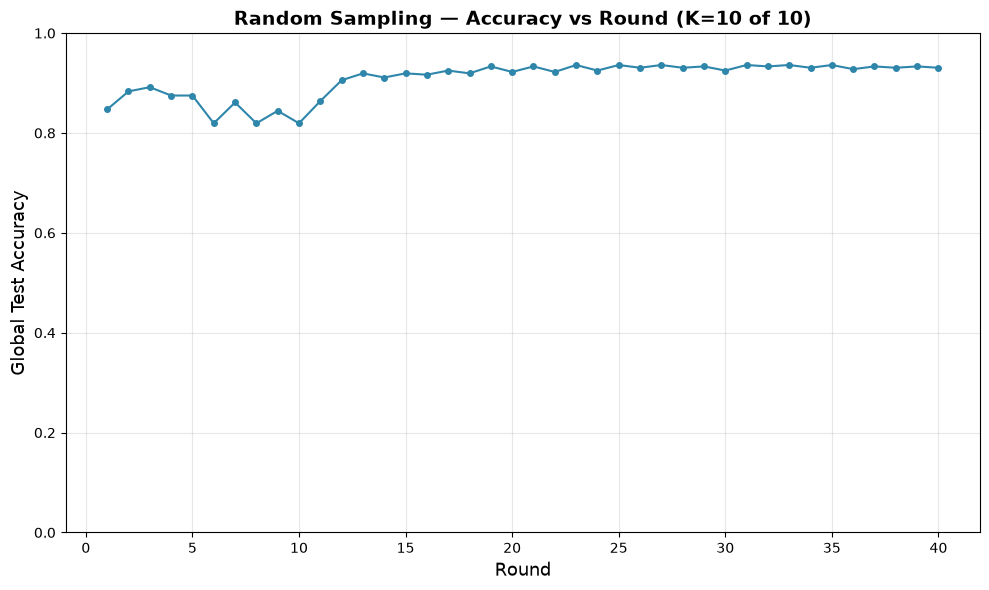

Final accuracy (round 40): 0.9306
Best accuracy: 0.9361 at round 23
Accuracy at round 1: 0.8472


In [ ]:
import io
import pandas as pd
import matplotlib.pyplot as plt

# Fetch CSV from the server VM
result = server_remotes[0].run(
    "cat federated-chi/baseline/results_baseline.csv",
    hide=True,
)
df = pd.read_csv(io.StringIO(result.stdout))

# Plot accuracy over rounds
plt.figure(figsize=(10, 6))
plt.plot(df["round"], df["global_accuracy"],
         color="#2e86ab", marker="o", linewidth=1.5, markersize=4)
plt.xlabel("Round", fontsize=13)
plt.ylabel("Global Test Accuracy", fontsize=13)
plt.title("Baseline — 10 clients, IID, 40 rounds",
          fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Print metrics
final_acc = df["global_accuracy"].iloc[-1]
best_acc = df["global_accuracy"].max()
best_round = df.loc[df["global_accuracy"].idxmax(), "round"]
print(f"Final accuracy (round {df['round'].iloc[-1]}): {final_acc:.4f}")
print(f"Best accuracy: {best_acc:.4f} at round {best_round}")
print(f"Accuracy at round 1: {df['global_accuracy'].iloc[0]:.4f}")

### Log in to resources

At this point, we should be able to log in to our resources over SSH! Run the following cell, and observe the output - you will see an SSH command for each of the nodes in your topology.

Now, you can open an SSH session on any of the nodes as follows:

-   In Jupyter, from the menu bar, use File \> New \> Terminal to open a new terminal.
-   Copy an SSH command from the output above, and paste it into the terminal.
-   You can repeat this process (open several terminals) to start a session on each node. Each terminal session will have a tab in the Jupyter environment, so that you can easily switch between them.

Alternatively, you can use your local terminal to log on to each node, if you prefer. (On your local terminal, you may need to also specify your key path as part of the SSH command, using the `-i` argument followed by the path to your private key.)

Now, you can open an SSH session on any of the nodes as follows:

-   In Jupyter, from the menu bar, use File \> New \> Terminal to open a new terminal.
-   Copy an SSH command from the output above, and paste it into the terminal.
-   You can repeat this process (open several terminals) to start a session on each node. Each terminal session will have a tab in the Jupyter environment, so that you can easily switch between them.

Alternatively, you can use your local terminal to log on to each node, if you prefer. (On your local terminal, you may need to also specify your key path as part of the SSH command, using the `-i` argument followed by the path to your private key.)

### Delete resources

When you finish your experiment, you should delete your resources! The following cells deletes all the resources in this experiment, freeing them for other experimenters.

In [ ]:
# delete the nodes
server_ids = [chi.server.get_server_id(n['name'] + "_" + username) for n in node_conf]
server_ips = [d['addr'] for s in server_ids for d in chi.server.show_server(s).addresses['public_net_' + username] if d['OS-EXT-IPS:type']=='floating']
for server_id in server_ids:
    chi.server.delete_server(server_id)

In [ ]:
# release the floating IP addresses used for SSH
for server_ip in server_ips:
    ip_details = chi.network.get_floating_ip(server_ip)
    chi.neutron().delete_floatingip(ip_details["id"])

In [ ]:
# delete the router used for public Internet access
router = chi.network.get_router("inet_router_" + username)
public_subnet = chi.network.get_subnet("public_subnet_" + username)
public_net = chi.network.get_network("public_net_" + username)
chi.network.remove_subnet_from_router(router.get("id"), public_subnet.get("id"))
chi.network.delete_router(router.get("id"))

In [ ]:
# delete the public network
chi.network.delete_subnet(public_subnet.get('id'))
chi.network.delete_network(public_net.get("id"))

In [ ]:
# delete the experiment networks
subnets = [chi.network.get_subnet("exp_subnet_" + n['name']  + '_' + username) for n in net_conf]
nets    = [chi.network.get_network("exp_" + n['name']  + '_' + username) for n in net_conf]
for subnet, net in zip(subnets, nets):
    chi.network.delete_subnet(subnet.get('id'))
    chi.network.delete_network(net.get('id'))